# Peak fitting for Scherrer analysis

Fit an isolated Bragg peak in a 1D GIWAXS integration, extract its FWHM, and convert that to a crystallite coherence length via the Scherrer equation. This notebook uses the helpers in `giwaxs_analysis.peak_fitting` — see [`src/giwaxs_analysis/peak_fitting.py`](../src/giwaxs_analysis/peak_fitting.py) for the implementation.

## Inputs

A CSV produced earlier by the batch-integration step in `04_azimuthal_integration.ipynb`, with:

- column 0: q-axis (Å⁻¹),
- remaining columns: integrated intensities, one per scan / sample / time-point.

All integrations should already be over the same angular range and the same q-grid.

## Lineshapes available

The package can fit either:

- **Gaussian on a linear background:** 
    - $y = mx + c + A \cdot e^{-(x - \mu)^2 / 2\sigma^2}$, 
    - where FWHM = $2\sqrt{2 \ln 2}\, \sigma \approx 2.355\,\sigma$.

- **Lorentzian on a linear background:** 
    - $y = mx + c + A / [\pi \sigma (1 + ((x - \mu)/\sigma)^2)]$, 
    - where FWHM = $2\sigma$.


## Scherrer equation

$$D_{hkl} = \frac{2\pi K}{\Delta q_{hkl}}$$

- For a given diffraction peak:

    - $D_{hkl}$ = crystallite coherence length [Å]
    - $K$ = Scherrer constant
    - ${\Delta q_{hkl}}$ = full width half maximum of the diffraction peak

with $K = 1$ by default or K = 0.9 (spherical), 0.94 (cubic) are also common.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from giwaxs_analysis import io, peak_fitting, plotting

## 1. Load the integrations CSV

Point this at your CSV. The default `skip_data_rows=2` matches the format the existing integration notebooks produce; pass `skip_data_rows=0` if you've already cleaned the file.

In [ ]:
CSV_PATH = '../data/example_integrations.csv'  # replace with your file

data = io.load_integrations_csv(CSV_PATH, skip_data_rows=2)
print(f'q-axis: {data.q.size} points, from {data.q.min():.3f} to {data.q.max():.3f} Å⁻¹')
print(f'{len(data.labels)} datasets: {data.labels}')

q-axis: 998 points, from 0.205 to 1.999 Å⁻¹
5 datasets: ['in_situ_GIWAXS_1', 'in_situ_GIWAXS_2', 'in_situ_GIWAXS_3', 'in_situ_GIWAXS_4', 'in_situ_GIWAXS_5']


## 2. Choose a peak and a fit window

Pick a tight q-range around the single peak you want to fit. Inspect the data first if you're not sure — only one peak should sit inside the window. If there are two overlapping peaks, see Section 7 of this notebook for a double fit.

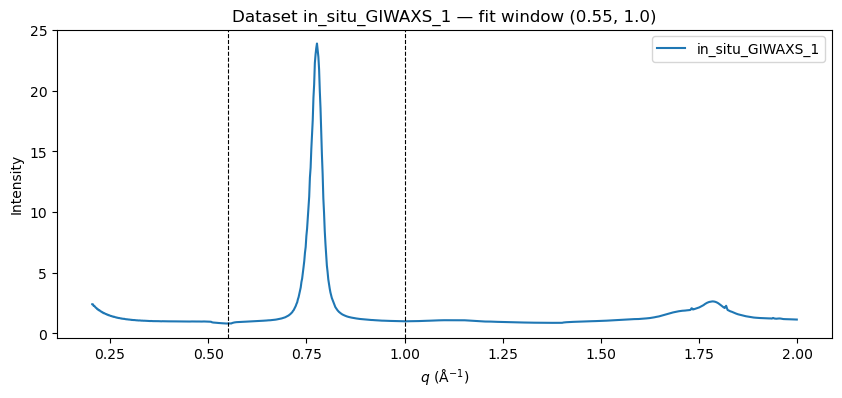

In [15]:
# Suggested range from the demo data

FIT_RANGE = (0.55, 1.0)
MODEL = 'lorentzian'   # 'gaussian' or 'lorentzian'

# Quick look at the first dataset (i.e. the first in the folder)
# so you can visually-check the window
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(data.q, data.intensities[:, 0], label=data.labels[0])
ax.axvline(FIT_RANGE[0], color='k', linestyle='--', linewidth=0.8)
ax.axvline(FIT_RANGE[1], color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel(r'$q$ (Å$^{-1}$)')
ax.set_ylabel('Intensity')
ax.set_title(f'Dataset {data.labels[0]} — fit window {FIT_RANGE}')
ax.legend()
plt.show()

## 3. Fit every dataset

`fit_peaks_batch` loops over every column of `intensities` and applies `fit_peak` to each. Failed fits are not silently dropped — they come back with `success=False` and `NaN` parameters so you can see them in the results table.

In [5]:
fits = peak_fitting.fit_peaks_batch(
    data.q,
    data.intensities,
    q_range=FIT_RANGE,
    model=MODEL,
    labels=data.labels,
)

results = pd.DataFrame([f.as_row() for f in fits])
results

,label,model,q_center,q_center_err,fwhm,fwhm_err,amplitude,sigma,background_slope,background_intercept,success,message
0,in_situ_GIWAXS_1,lorentzian,0.775570,0.000104,0.031326,0.000328,1.167376,0.015663,0.063257,0.599599,True,ok
1,in_situ_GIWAXS_2,lorentzian,0.775441,0.000104,0.031108,0.000329,1.545353,0.015554,0.149212,0.395434,True,ok
2,in_situ_GIWAXS_3,lorentzian,0.774968,0.000104,0.031023,0.000330,1.914540,0.015512,0.256076,0.171758,True,ok
3,in_situ_GIWAXS_4,lorentzian,0.774882,0.000104,0.030857,0.000328,2.185280,0.015429,0.339826,0.001676,True,ok
4,in_situ_GIWAXS_5,lorentzian,0.774948,0.000103,0.030695,0.000325,2.388153,0.015347,0.401038,-0.118557,True,ok


## 4. Inspect each fit

Two-panel plot per dataset: data + model on top, residuals on the bottom. Residuals should look like noise around zero; structure in the residuals means the model is wrong (try the other lineshape, or check whether you've actually got two peaks in there).

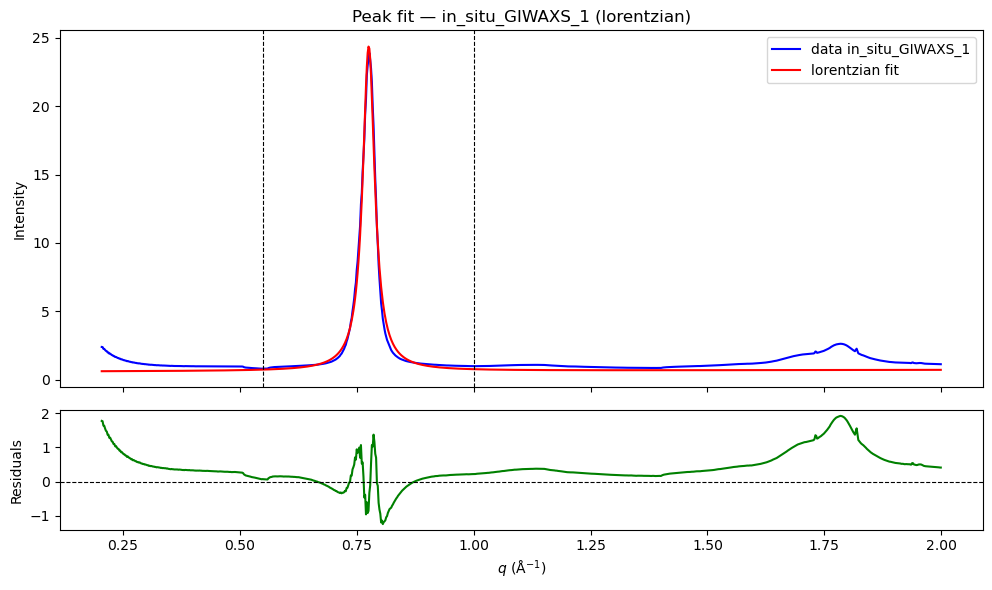

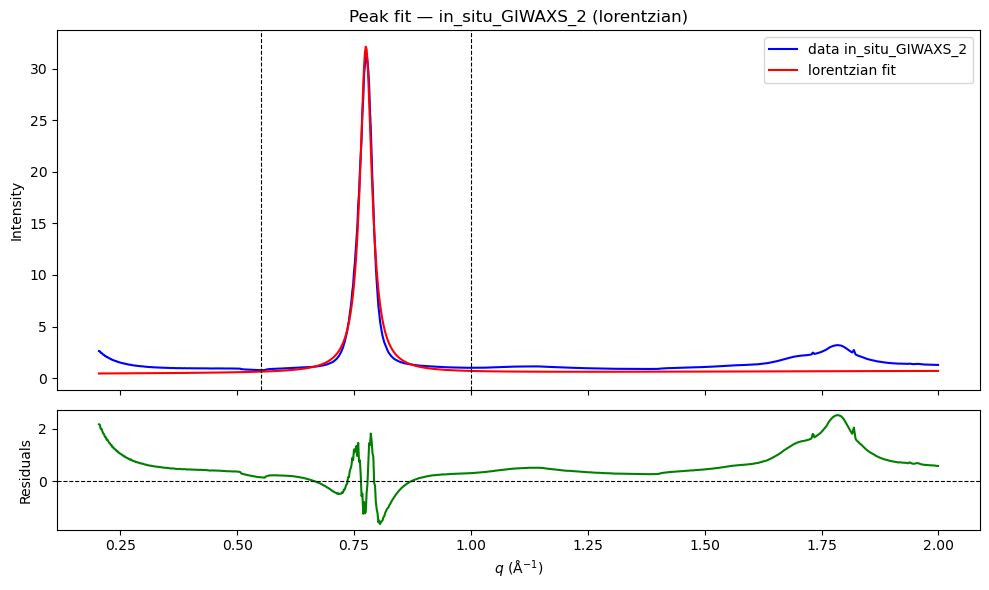

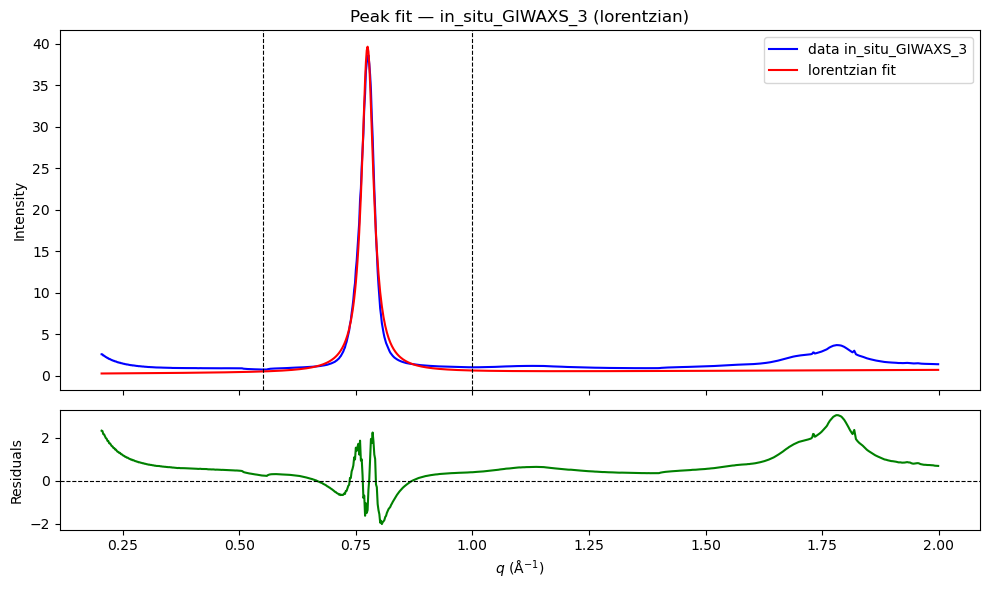

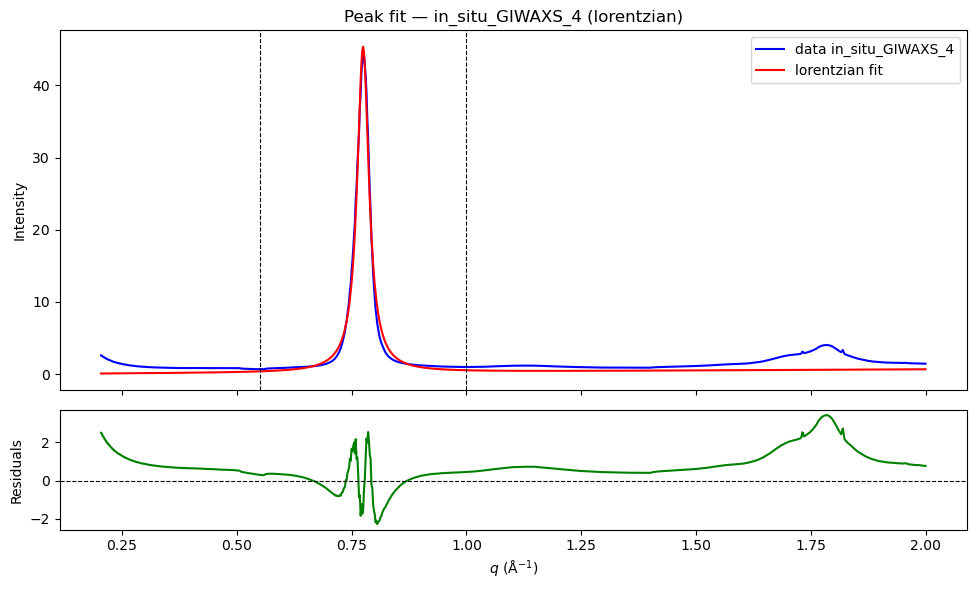

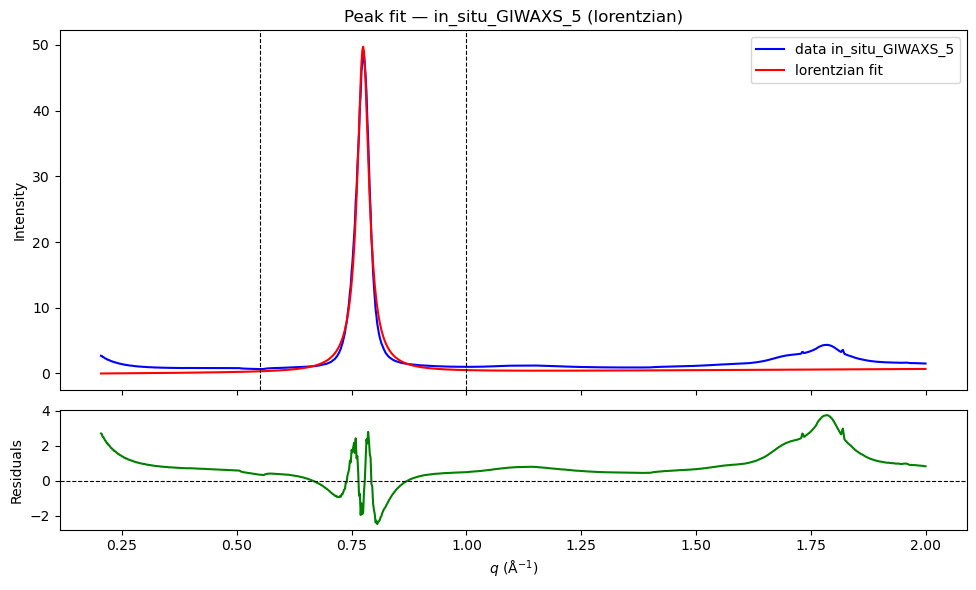

In [6]:
for fit, col in zip(fits, range(data.intensities.shape[1])):
    if not fit.success:
        print(f'Skipping {fit.label}: {fit.message}')
        continue
    plotting.plot_peak_fit(
        data.q,
        data.intensities[:, col],
        fit,
        q_range=FIT_RANGE,
    )
    plt.show()

## 5. Scherrer crystallite size

`scherrer(fwhm)` takes a FWHM in Å⁻¹ and returns the coherence length. Default unit is nm; pass `unit='A'` for Ångström, and `K=` for a different Scherrer constant.

In [7]:
results['D_nm'] = peak_fitting.scherrer(results['fwhm'].to_numpy(), K=1.0, unit='nm')
# Propagate error: D ∝ 1/FWHM, so ΔD/D = ΔFWHM/FWHM
results['D_nm_err'] = results['D_nm'] * (results['fwhm_err'] / results['fwhm'])
results[['label', 'q_center', 'q_center_err', 'fwhm', 'fwhm_err', 'D_nm', 'D_nm_err']]

,label,q_center,q_center_err,fwhm,fwhm_err,D_nm,D_nm_err
0,in_situ_GIWAXS_1,0.775570,0.000104,0.031326,0.000328,20.057345,0.210263
1,in_situ_GIWAXS_2,0.775441,0.000104,0.031108,0.000329,20.197894,0.213414
2,in_situ_GIWAXS_3,0.774968,0.000104,0.031023,0.000330,20.253231,0.215693
3,in_situ_GIWAXS_4,0.774882,0.000104,0.030857,0.000328,20.362210,0.216299
4,in_situ_GIWAXS_5,0.774948,0.000103,0.030695,0.000325,20.470021,0.216514


## 6. Plot D vs label (optional)

If your dataset labels are an ordinal variable (temperature, time, anneal step...), uncomment and adjust the cell below.

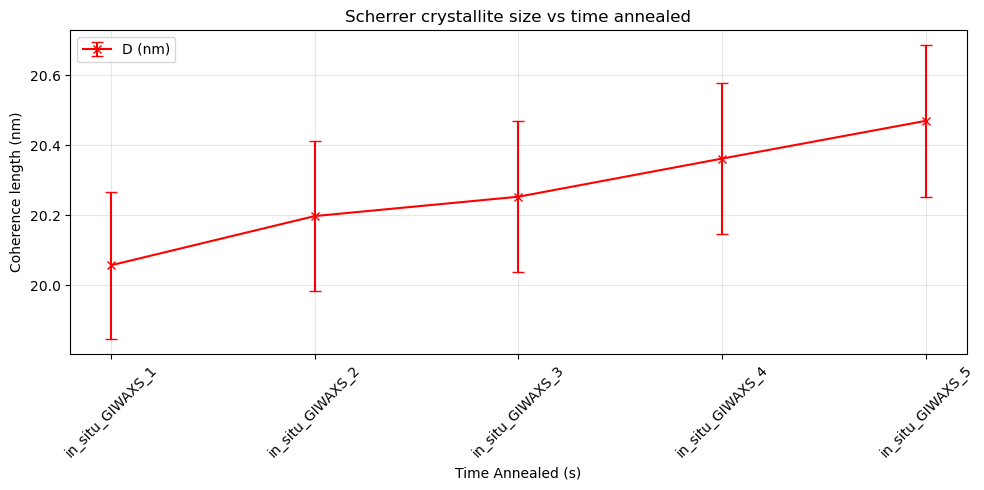

In [11]:
# Example: dataset labels are temperatures in °C
x_values = np.arange(len(results))
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    x_values, results['D_nm'], yerr=results['D_nm_err'],
    marker='x', linestyle='-', color='r', capsize=4, label='D (nm)',
)
ax.set_xticks(x_values)
ax.set_xticklabels(results['label'], rotation=45)
ax.set_xlabel('Time Annealed (s)')
ax.set_ylabel('Coherence length (nm)')
ax.set_title('Scherrer crystallite size vs time annealed')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 7. Overlapping peaks (optional)

When one Lorentzian isn't enough — e.g. a shoulder, or two closely-spaced reflections — use `fit_double_lorentzian`. Pick a wider `q_range` covering both peaks, and give `initial_centres=(μ1, μ2)` eyeballed from a plot.

In [ ]:
# # Example: fit the 'RT' dataset around 1.25 and 1.45 Å⁻¹
# col = data.labels.index('RT')
# overlap_fit = peak_fitting.fit_double_lorentzian(
#     data.q,
#     data.intensities[:, col],
#     q_range=(1.1, 1.6),
#     initial_centres=(1.25, 1.45),
#     initial_widths=(0.07, 0.02),
#     label='RT',
# )
# plotting.plot_double_peak_fit(data.q, data.intensities[:, col], overlap_fit, q_range=(1.1, 1.6))
# plt.show()
# print(f'Peak 1: q={overlap_fit.q_center_1:.4f} ± {overlap_fit.q_center_1_err:.4f}, '
#       f'FWHM={overlap_fit.fwhm_1:.4f} ± {overlap_fit.fwhm_1_err:.4f}')
# print(f'Peak 2: q={overlap_fit.q_center_2:.4f} ± {overlap_fit.q_center_2_err:.4f}, '
#       f'FWHM={overlap_fit.fwhm_2:.4f} ± {overlap_fit.fwhm_2_err:.4f}')